# LG-OMPC, part 3 — Automated Incident Response 🚨

This notebook breaks entirely from the "robotics" aesthetic to prove a crucial point: **the framework does not know what physical space is.**

Here, the environment is an abstract topological graph—a company's computer network. An active infection is spreading across vulnerable nodes. The agent (an active automated System Admin) must triage the situation to protect business-critical infrastructure, sacrificing availability if necessary to stop the spread.

We will watch the discrete MPC dynamically solve a high-stakes DevOps problem entirely governed by language.

In [1]:
# --- Setup: make package visible, load .env ---
import os
import sys
from pathlib import Path

def find_repo_root(start: Path):
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    return start

REPO_ROOT = find_repo_root(Path.cwd())
EXAMPLE_DIR = REPO_ROOT / "examples" / "incident_response"
for p in (REPO_ROOT / "src", EXAMPLE_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

def load_dotenv(path):
    if not path.exists(): return False
    for line in path.read_text().splitlines():
        if line.strip() and not line.startswith("#") and "=" in line:
            k, _, v = line.partition("=")
            os.environ.setdefault(k.strip(), v.strip())
    return True

HAS_API_KEY = load_dotenv(REPO_ROOT / ".env") and bool(os.environ.get("LLM_API_KEY"))
print(f"API key set : {HAS_API_KEY}  (model: {os.environ.get('LLM_MODEL', 'gpt-5.2')})")

API key set : True  (model: gpt-5.2)


In [2]:
import matplotlib.pyplot as plt

def draw_network(env, ax=None, title=None):
    """Render the network graph: Red = infected, Gray = isolated, Green = healthy."""
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(6, 4))
        
    # Hardcoded topological positions
    positions = {
        "w1": (0, 2), "w2": (0, 1), "w3": (0, 0),
        "switch": (1, 1),
        "db": (2, 1.5), "payment": (2, 0.5)
    }
    
    # Draw edges first
    for u_name, (ux, uy) in positions.items():
        u = env.entity(u_name)
        for v_name in u.state["connections"]:
            if u_name < v_name: # lex order to avoid double drawing
                v = env.entity(v_name)
                active = not u.state["isolated"] and not v.state["isolated"]
                color = "#475569" if active else "#cbd5e1"
                ls = "-" if active else ":"
                lw = 2 if active else 1
                ax.plot([ux, positions[v_name][0]], [uy, positions[v_name][1]], 
                        color=color, ls=ls, lw=lw, zorder=1)
                
    # Draw nodes
    for name, (nx, ny) in positions.items():
        s = env.entity(name)
        if s.state["infected"]:
            color = "#ef4444"     # Red (infected)
        elif s.state["isolated"]:
            color = "#94a3b8"     # Gray (isolated)
        else:
            color = "#22c55e"     # Green (online/healthy)
            
        ax.scatter([nx], [ny], s=600 + s.state["value"]*4, color=color, 
                   edgecolor="#1e293b", lw=1.5, zorder=2)
        ax.text(nx, ny - 0.25, f"{name}\n(v={s.state['value']})", 
                ha="center", va="top", fontsize=9)
        
    ax.set_aspect("equal")
    ax.axis("off")
    
    total_val = sum(s.state["value"] for s in env.servers() if not s.state["isolated"] and not s.state["infected"])
    ax.set_title(f"{title}\nActive Business Value: {total_val}", fontsize=11, weight="bold")
    
    if own:
        plt.tight_layout()
        plt.show()

print("Network renderer ready")

Network renderer ready


## The Topology

We build the world with 6 servers. 
- Three low-value **worker nodes** (infected).
- A central **switch** (clean).
- The high-value **database** and **payment gateway** (clean, but dangerously close to the switch).

If the switch becomes infected, it spreads to the database and payment systems immediately on the next turn. Let's see the initial outbreak state.

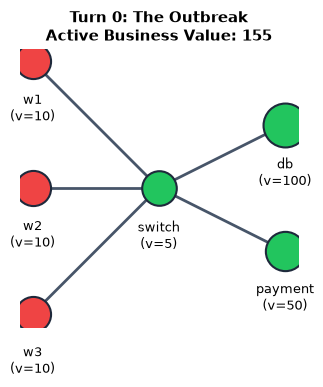

The LLM receives the network structure dynamically via JSON:
{
  "goal": "",
  "entities": [
    {
      "name": "db",
      "kind": "server",
      "role": "inert",
      "state": {
        "infected": false,
        "isolated": false,
        "value": 100,
        "connections": [
          "switch"
        ]
      },
      "outgoing_actions": [],
      "incoming_actions": [],
      "purposes": []
    },
    {
      "name": "payment",
      "kind": "server",
      "role": "inert",
      "state": {
        "infected": false,
        "isolated": false,
        "value": 50,
        "connections": [
          "switch"
        ]
      },
      "outgoing_actions": [],
      "incoming_actions": [],
      "purposes": []
    },
    {
      "name": "switch",
 ...
}


In [12]:
import importlib
import world
importlib.reload(world)
from world import build_world
from lg_ompc import describe

env = build_world()
draw_network(env, title="Turn 0: The Outbreak")

desc = describe(env)
print("The LLM receives the network structure dynamically via JSON:")
print(desc.to_prompt_json()[:700], "...\n}")

## Affordances (What the Admin can do)

The Admin script has 3 abilities:
1. **`clean(server)`**: Cures the infection.
2. **`isolate(server)`**: Digitally disconnects the server. It loses all Business Value, but infection cannot cross its edges.
3. **`reconnect(server)`**: Restores an isolated server to the network so it provides value again.

Because `clean` takes a full turn and can only target one node at a time, the admin *cannot* clean all three workers before the infection reaches the Database. The MPC will have to discover the classic IT containment strategy: **Quarantine the hub, sanitize the spokes, restore the network.**

In [8]:
from lg_ompc import compile_objective, synthesize_objective_async

# Fallback objective perfectly encodes standard business rules:
# 1. Infected systems are catastrophic liabilities (-1000 * value).
# 2. Online, clean systems provide revenue (+1 * value).
# 3. Isolated systems are useless to the business (0 value) but stop damage.
FALLBACK_OBJECTIVE = '''
def evaluate_objective(world, history):
    score = 0.0
    servers = [e for e in world.entities.values() if getattr(e, "kind", "") == "server"]
    
    for s in servers:
        if s.state.get("infected"):
            score -= 1000.0 * s.state.get("value")
        elif not s.state.get("isolated"):
            score += s.state.get("value")
            
    score -= 0.1 * len(history)  # slight penalty for taking too long
    return score
'''

spec = None
if HAS_API_KEY:
    print(f"Synthesizing Incident Response playbook with {os.environ.get('LLM_MODEL')}...")
    spec = await synthesize_objective_async(build_world())
    objective_code = spec.code
else:
    print("No API key. Using Fallback business logic.")
    objective_code = FALLBACK_OBJECTIVE

objective = compile_objective(objective_code)

if spec:
    print("\nLLM Rationale:")
    print(spec.rationale)
else:
    print("\nExecuting fallback objective code.")

Synthesizing Incident Response playbook with gpt-5.2...

LLM Rationale:
Objective shaped for a short-horizon MPC: big negative for any infection of high-value assets (db/payment), a strong per-step gradient to isolate infected workstations, and a moderate incentive to restore connectivity of clean critical services. Effort penalties are kept small to avoid stalling while work remains.


## Running the MPC Controller

With a horizon of 5, the planner looks deep enough into the tree to realize that if it doesn't isolate the switch *immediately*, the database will contract the infection in exactly 2 turns, causing massive negative score.

Watch the history output below. The controller is completely autonomous and discovers the sequence of triage intuitively.

In [ ]:
from lg_ompc import Controller
import copy

HORIZON = 5
mission = build_world()
result = Controller(horizon=HORIZON, max_steps=10).run(mission, objective=objective)

print("Executed Incident Response Plan:")
for i, a in enumerate(result.history, 1):
    print(f"  Turn {i}: {a}")
    
# Save frames for filmstrip visualization
replay = build_world()
frames = [(copy.deepcopy(replay), "T=0: Outbreak Start")]

for i, a in enumerate(result.history, 1):
    replay.apply(a)
    frames.append((copy.deepcopy(replay), f"T={i}: {a.name}({a.target})"))

In [ ]:
# Draw the incident response filmstrip!
cols = min(6, len(frames))
rows = (len(frames) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
axes = axes.flatten() if rows > 1 else (axes if cols > 1 else [axes])

for idx, (frame, title) in enumerate(frames):
    draw_network(frame, ax=axes[idx], title=title)

# hide unused subplots
for empty_ax in axes[len(frames):]:
    empty_ax.axis('off')

plt.tight_layout()
plt.show()